## A2 

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/lucja/Desktop/Machine Learning/Assignment1/Cars.csv")

df.shape

(8128, 13)

In [67]:
# fix the random seed so results are reproducible across re-runs
np.random.seed(999)

In [68]:
# delete duplicates
print("Amount of duplicates: ", df.duplicated().sum())
df = df.drop_duplicates()
df.shape

Amount of duplicates:  1202


(6926, 13)

In [69]:
# mapping - each text category is assigned a number
owner_map = {'First Owner':1, 'Second Owner':2, 'Third Owner':3,
             'Fourth & Above Owner':4, 'Test Drive Car':5}
df['owner'] = df['owner'].map(owner_map)

# we keep only the rows where fuel is not CNG or LPG
df = df[~df['fuel'].isin(['CNG','LPG'])]

# we split the text by space, take only the number, and convert it to float
df['mileage'] = df['mileage'].str.split(' ').str[0].astype(float)
df['engine'] = df['engine'].str.split(' ').str[0].astype(float)
df['max_power'] = df['max_power'].str.split(' ').str[0].replace('', np.nan).astype(float)

# we split the column name by space and take the first word as a new column name
df['brand'] = df['name'].str.split(' ').str[0]
df = df.drop(columns=['name'])
df = df.drop(columns=['torque'])

# remove Test Drive Cars
df = df[df['owner'] != 5]

print(df.shape)
df.head()

(6827, 12)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


In [70]:
# fill missing values in numeric columns with the median
for col in ['mileage', 'engine', 'max_power', 'seats']:
    df[col] = df[col].fillna(df[col].median())

print(df.isna().sum())

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
brand            0
dtype: int64


In [71]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['transmission'] = le.fit_transform(df['transmission'])
df['seller_type'] = le.fit_transform(df['seller_type'])

df_encoded = pd.get_dummies(df, columns=['fuel', 'brand'], drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (6827, 42)


,year,selling_price,km_driven,seller_type,transmission,owner,mileage,engine,max_power,seats,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,450000,145500,1,1,1,23.40,1248.0,74.00,5.0,...,False,False,False,False,False,False,False,False,False,False
1,2014,370000,120000,1,1,2,21.14,1498.0,103.52,5.0,...,False,False,False,False,False,True,False,False,False,False
2,2006,158000,140000,1,1,3,17.70,1497.0,78.00,5.0,...,False,False,False,False,False,False,False,False,False,False
3,2010,225000,127000,1,1,1,23.00,1396.0,90.00,5.0,...,False,False,False,False,False,False,False,False,False,False
4,2007,130000,120000,1,1,1,16.10,1298.0,88.20,5.0,...,False,False,False,False,False,False,False,False,False,False


In [72]:
from sklearn.model_selection import KFold


# --- regularization classes ---
class Normal:
    """No regularization - lets plain linear regression go through the
    same LinearRegression class as Lasso/Ridge."""
    def __init__(self, l=0):
        self.l = l
    def __call__(self, theta):
        return 0
    def derivation(self, theta):
        return 0


class Lasso:
    def __init__(self, l):
        self.l = l
    def __call__(self, theta):  # __call__ allows us to call class as method
        return self.l * np.sum(np.abs(theta))
    def derivation(self, theta):
        return self.l * np.sign(theta)


class Ridge:
    def __init__(self, l):
        self.l = l
    def __call__(self, theta):
        return self.l * np.sum(np.square(theta))
    def derivation(self, theta):
        return self.l * 2 * theta


class Elastic:
    def __init__(self, l, l_ratio=0.5):
        self.l = l
        self.l_ratio = l_ratio
    def __call__(self, theta):
        l1 = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2 = (1 - self.l_ratio) * self.l * np.sum(np.square(theta))
        return l1 + l2
    def derivation(self, theta):
        l1 = self.l_ratio * self.l * np.sign(theta)
        l2 = 2 * self.l * (1 - self.l_ratio) * theta
        return l1 + l2


# --- main class ---
class LinearRegression(object):

    kfold = KFold(n_splits=5)

    def __init__(self, regularization, lr=0.001, method='batch', num_epochs=500,
                 bs=50, cv=kfold, init_method='zeros', use_momentum=False,
                 momentum=0.9):
        self.lr = lr
        self.num_epochs = num_epochs
        self.bs = bs
        self.method = method
        self.cv = cv
        self.regularization = regularization

        # ---- Task 1 additions ----
        self.init_method = init_method       # 'zeros' or 'xavier'
        self.use_momentum = use_momentum     # bool
        self.momentum = momentum             # in (0, 1)

    # mse
    def mse(self, ytrue, ypred):
        # ytrue shape: (m, ) ==> m = number of samples
        return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]

    # Task 1: r2 score
    def r2(self, ytrue, ypred):
        ss_res = np.sum((ytrue - ypred) ** 2)
        ss_tot = np.sum((ytrue - np.mean(ytrue)) ** 2)
        return 1 - (ss_res / ss_tot)

    # Task 1: weight initialization (zeros or xavier)
    def _initialize_theta(self, n):
        # n = number of inputs (features)
        if self.init_method == 'xavier':
            lower, upper = -(1.0 / np.sqrt(n)), (1.0 / np.sqrt(n))
            numbers = np.random.rand(n)
            return lower + numbers * (upper - lower)
        else:  # zeros
            return np.zeros(n)

    # fit
    def fit(self, X_train, y_train):

        # create a list for keeping kfold scores
        self.kfold_scores = list()
        self.kfold_r2_scores = list()

        # variable to know our loss is not improving anymore
        self.val_loss_old = np.inf

        # cross validation
        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):

            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val = X_train[val_idx]
            y_cross_val = y_train[val_idx]

            self.theta = self._initialize_theta(X_cross_train.shape[1])
            self.prev_step = np.zeros_like(self.theta)  # for momentum

            for epoch in range(self.num_epochs):

                # Shuffle the data a little so that order does not impact our model
                perm = np.random.permutation(X_cross_train.shape[0])
                X_cross_train = X_cross_train[perm]
                y_cross_train = y_cross_train[perm]

                if self.method == 'mini':
                    for batch_idx in range(0, X_cross_train.shape[0], self.bs):
                        X_method_train = X_cross_train[batch_idx:batch_idx + self.bs]
                        y_method_train = y_cross_train[batch_idx:batch_idx + self.bs]
                        train_loss = self._train(X_method_train, y_method_train)
                elif self.method == 'sto':
                    for i in range(X_cross_train.shape[0]):
                        X_method_train = X_cross_train[i:i + 1]
                        y_method_train = y_cross_train[i:i + 1]
                        train_loss = self._train(X_method_train, y_method_train)
                else:  # batch
                    X_method_train = X_cross_train
                    y_method_train = y_cross_train
                    train_loss = self._train(X_method_train, y_method_train)

                yhat_val = self.predict(X_cross_val)
                val_loss_new = self.mse(y_cross_val, yhat_val)

                # early stopping
                if np.allclose(val_loss_new, self.val_loss_old):
                    break
                self.val_loss_old = val_loss_new

            val_r2_new = self.r2(y_cross_val, yhat_val)
            self.kfold_scores.append(val_loss_new)
            self.kfold_r2_scores.append(val_r2_new)
            print(f"Fold {fold}: mse={val_loss_new:.4f}, r2={val_r2_new:.4f}")

    # train
    def _train(self, X, y):
        # X shape: (m, n); y shape: (m, ); theta shape: (n, )

        # 1. predict
        yhat = self.predict(X)

        # 2. grad
        m = X.shape[0]
        grad = (1 / m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)

        # gradient clipping for numerical stability (large lr + momentum + sto
        # can otherwise overflow)
        grad_norm = np.linalg.norm(grad)
        if grad_norm > 5.0:
            grad = grad * (5.0 / grad_norm)

        # 3. update
        step = self.lr * grad
        if self.use_momentum:
            new_theta = self.theta - step + self.momentum * self.prev_step
        else:
            new_theta = self.theta - step

        if np.all(np.isfinite(new_theta)):
            self.theta = new_theta
        self.prev_step = step

        # return
        return self.mse(y, yhat)

    # predict
    def predict(self, X):
        return X @ self.theta  # (m, n) @ (n, ) = (m, )  <===== y

    # get theta
    def _coef(self):
        return self.theta[1:]

    # get bias
    def _bias(self):
        return self.theta[0]

    # Task 1: feature importance plot
    def plot_feature_importance(self, feature_names=None, top_n=15):
        """
        Plots feature importance based on |coefficient|. Assumes the
        intercept is the first entry in theta, and that features were
        scaled prior to fitting so magnitudes are comparable.
        """
        coefs = self._coef()

        if feature_names is None:
            feature_names = [f'x{i}' for i in range(len(coefs))]

        importance = np.abs(coefs)
        order = np.argsort(importance)[::-1][:top_n]

        plt.figure(figsize=(8, 6))
        plt.barh([feature_names[i] for i in order][::-1], importance[order][::-1])
        plt.xlabel('|coefficient|')
        plt.title('Feature importance (coefficient magnitude)')
        plt.tight_layout()
        plt.show()

        return dict(zip([feature_names[i] for i in order], importance[order]))


# --- convenience subclasses (inherit LinearRegression) ---
class NormalRegression(LinearRegression):
    def __init__(self, method, lr, **kwargs):
        self.regularization = Normal()
        super().__init__(self.regularization, lr, method, **kwargs)


class LassoRegression(LinearRegression):
    def __init__(self, method, lr, l, **kwargs):
        self.regularization = Lasso(l)
        super().__init__(self.regularization, lr, method, **kwargs)


class RidgeRegression(LinearRegression):
    def __init__(self, method, lr, l, **kwargs):
        self.regularization = Ridge(l)
        super().__init__(self.regularization, lr, method, **kwargs)


class ElasticRegression(LinearRegression):
    def __init__(self, method, lr, l, l_ratio=0.5, **kwargs):
        self.regularization = Elastic(l, l_ratio)
        super().__init__(self.regularization, lr, method, **kwargs)

In [73]:
# quick sanity check on synthetic data
X_demo = np.random.randn(300, 3)
true_theta = np.array([2.0, -1.0, 0.5])
y_demo = X_demo @ true_theta + np.random.randn(300) * 0.1
X_demo = np.hstack([np.ones((300, 1)), X_demo])  # intercept column

for init in ['zeros', 'xavier']:
    for mom in [False, True]:
        model = NormalRegression(method='batch', lr=0.1, num_epochs=50,
                                  init_method=init, use_momentum=mom, momentum=0.8)
        model.fit(X_demo, y_demo)
        print(f"init={init:7s} momentum={mom}: mean CV R2 = {np.mean(model.kfold_r2_scores):.4f}\n")

Fold 0: mse=0.0141, r2=0.9976
Fold 1: mse=0.0090, r2=0.9983
Fold 2: mse=0.0109, r2=0.9978
Fold 3: mse=0.0162, r2=0.9973
Fold 4: mse=0.0125, r2=0.9981
init=zeros   momentum=False: mean CV R2 = 0.9978

Fold 0: mse=0.7172, r2=0.8787
Fold 1: mse=0.5670, r2=0.8936
Fold 2: mse=0.5334, r2=0.8926
Fold 3: mse=0.6558, r2=0.8893
Fold 4: mse=0.8033, r2=0.8771
init=zeros   momentum=True: mean CV R2 = 0.8863

Fold 0: mse=0.0140, r2=0.9976
Fold 1: mse=0.0090, r2=0.9983
Fold 2: mse=0.0109, r2=0.9978
Fold 3: mse=0.0161, r2=0.9973
Fold 4: mse=0.0126, r2=0.9981
init=xavier  momentum=False: mean CV R2 = 0.9978

Fold 0: mse=0.5941, r2=0.8995
Fold 1: mse=0.6564, r2=0.8768
Fold 2: mse=0.5382, r2=0.8917
Fold 3: mse=0.5550, r2=0.9063
Fold 4: mse=1.0912, r2=0.8331
init=xavier  momentum=True: mean CV R2 = 0.8815



In [74]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

y = np.log(df_encoded['selling_price'])   # predict log(price), same as A1
X = df_encoded.drop(columns=['selling_price'])
feature_names = X.columns.tolist()

X = X.values.astype(float)
y = y.values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=999)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# polynomial features (degree=2), built from the scaled features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_s)
X_test_poly = poly.transform(X_test_s)

def add_intercept(A):
    return np.hstack([np.ones((A.shape[0], 1)), A])

X_train_plain = add_intercept(X_train_s)
X_test_plain = add_intercept(X_test_s)
X_train_poly_i = add_intercept(X_train_poly)
X_test_poly_i = add_intercept(X_test_poly)

print('X_train_plain:', X_train_plain.shape, ' X_train_poly_i:', X_train_poly_i.shape)

X_train_plain: (5461, 42)  X_train_poly_i: (5461, 903)


In [75]:
import mlflow

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('A2-Car-Price-Prediction')

SEARCH_EPOCHS = 25
SEARCH_BS = 64
LAMBDA = 0.1  # fixed regularization strength used for the lasso/ridge comparison

def build_model(model_type, method, lr, init_method, momentum_flag):
    kwargs = dict(num_epochs=SEARCH_EPOCHS, bs=SEARCH_BS, init_method=init_method,
                  use_momentum=momentum_flag, momentum=0.8)
    if model_type in ('normal', 'poly'):
        return NormalRegression(method=method, lr=lr, **kwargs)
    elif model_type == 'lasso':
        return LassoRegression(method=method, lr=lr, l=LAMBDA, **kwargs)
    elif model_type == 'ridge':
        return RidgeRegression(method=method, lr=lr, l=LAMBDA, **kwargs)
    else:
        raise ValueError(model_type)

In [76]:
import itertools
import time
import os

RESULTS_CSV = 'experiment_results.csv'

model_types = ['normal', 'lasso', 'ridge', 'poly']
momentum_options = [False, True]
methods = ['sto', 'mini', 'batch']
init_methods = ['zeros', 'xavier']
lrs = [0.01, 0.001, 0.0001]

# checkpoint: if this cell gets interrupted, re-running it resumes
# from where it left off instead of starting over
if os.path.exists(RESULTS_CSV):
    done_df = pd.read_csv(RESULTS_CSV)
    done_keys = set(zip(done_df.model_type, done_df.momentum, done_df.method,
                         done_df.init_method, done_df.lr))
    results = done_df.to_dict('records')
else:
    done_keys = set()
    results = []

total = len(model_types) * len(momentum_options) * len(methods) * len(init_methods) * len(lrs)
combo_id = len(results)
start = time.time()

for model_type, mom, method, init, lr in itertools.product(
        model_types, momentum_options, methods, init_methods, lrs):

    key = (model_type, mom, method, init, lr)
    if key in done_keys:
        continue

    combo_id += 1
    X_tr = X_train_poly_i if model_type == 'poly' else X_train_plain

    model = build_model(model_type, method, lr, init, mom)
    try:
        model.fit(X_tr, y_train)
        mean_r2 = float(np.mean(model.kfold_r2_scores))
        mean_mse = float(np.mean(model.kfold_scores))
    except Exception as e:
        mean_r2, mean_mse = np.nan, np.nan
        print('FAILED:', key, e)

    with mlflow.start_run(run_name=f'{model_type}-{method}-{init}-mom{mom}-lr{lr}'):
        mlflow.log_params(dict(model_type=model_type, momentum=mom, method=method,
                                init_method=init, lr=lr))
        mlflow.log_metric('mean_r2', mean_r2 if np.isfinite(mean_r2) else -999)
        mlflow.log_metric('mean_mse', mean_mse if np.isfinite(mean_mse) else -1)

    results.append(dict(model_type=model_type, momentum=mom, method=method,
                         init_method=init, lr=lr, mean_r2=mean_r2, mean_mse=mean_mse))
    pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)

    if combo_id % 20 == 0 or combo_id == total:
        print(f'[{combo_id}/{total}] done (elapsed {time.time()-start:.0f}s)')

results_df = pd.DataFrame(results).sort_values('mean_r2', ascending=False)
print('\nTop 10 configs by mean CV R2:')
results_df.head(10)


Top 10 configs by mean CV R2:


,model_type,momentum,method,init_method,lr,mean_r2,mean_mse
42,lasso,False,mini,zeros,0.010,0.773606,0.129742
45,lasso,False,mini,xavier,0.010,0.773440,0.129875
40,lasso,False,sto,xavier,0.001,0.759656,0.137922
39,lasso,False,sto,xavier,0.010,0.758580,0.137506
37,lasso,False,sto,zeros,0.001,0.755629,0.140169
57,lasso,True,sto,xavier,0.010,0.755387,0.140236
54,lasso,True,sto,zeros,0.010,0.755333,0.139937
55,lasso,True,sto,zeros,0.001,0.753976,0.141017
58,lasso,True,sto,xavier,0.001,0.753904,0.141065
36,lasso,False,sto,zeros,0.010,0.748241,0.144705


### MLflow UI

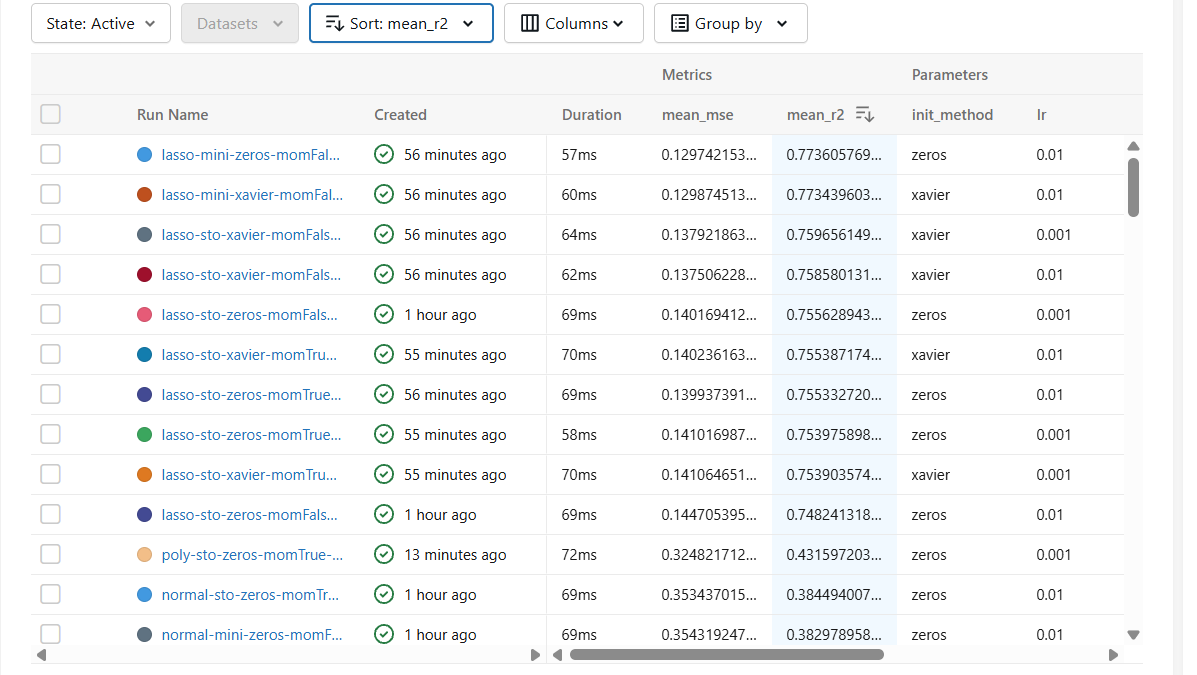
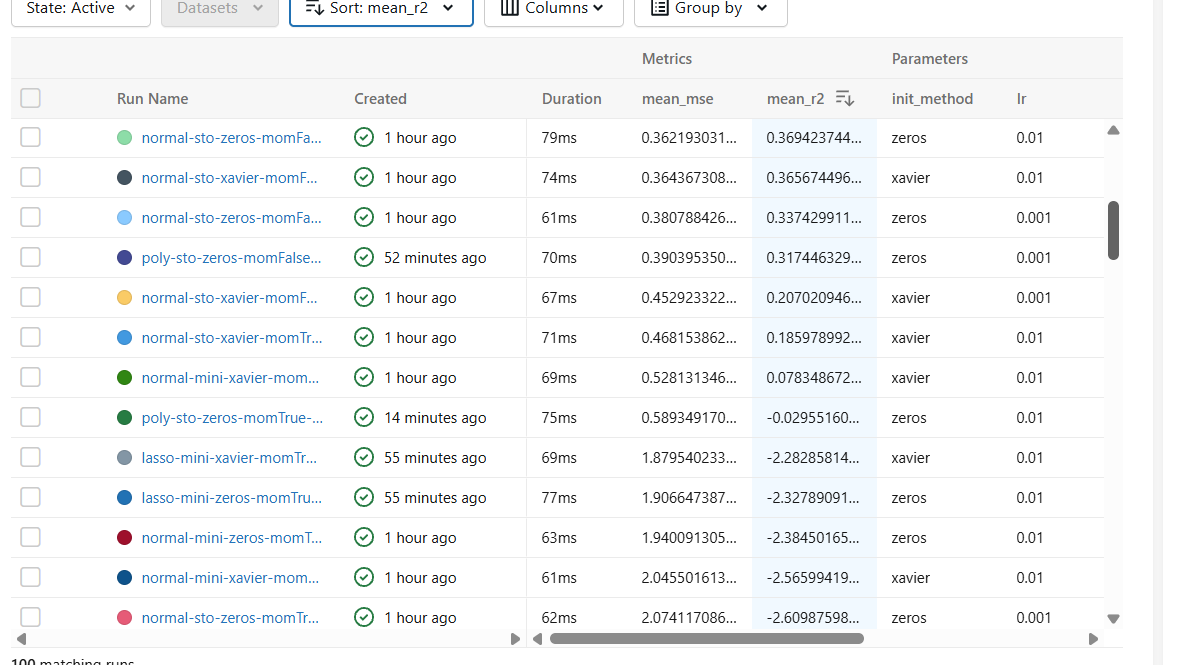
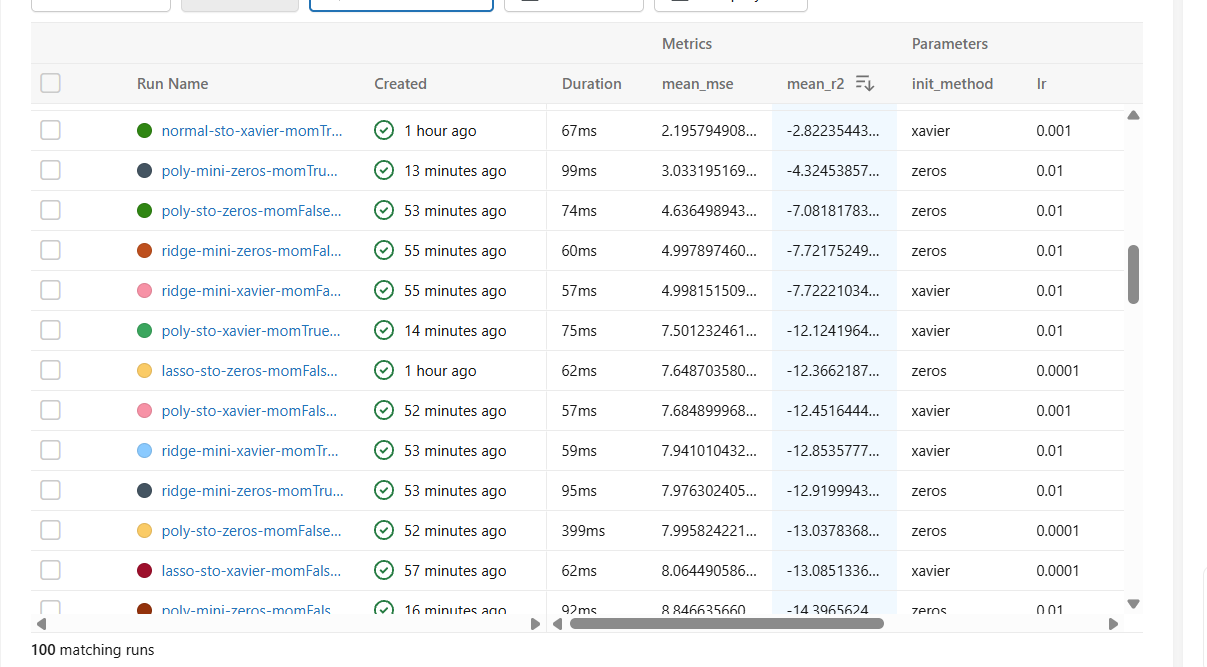
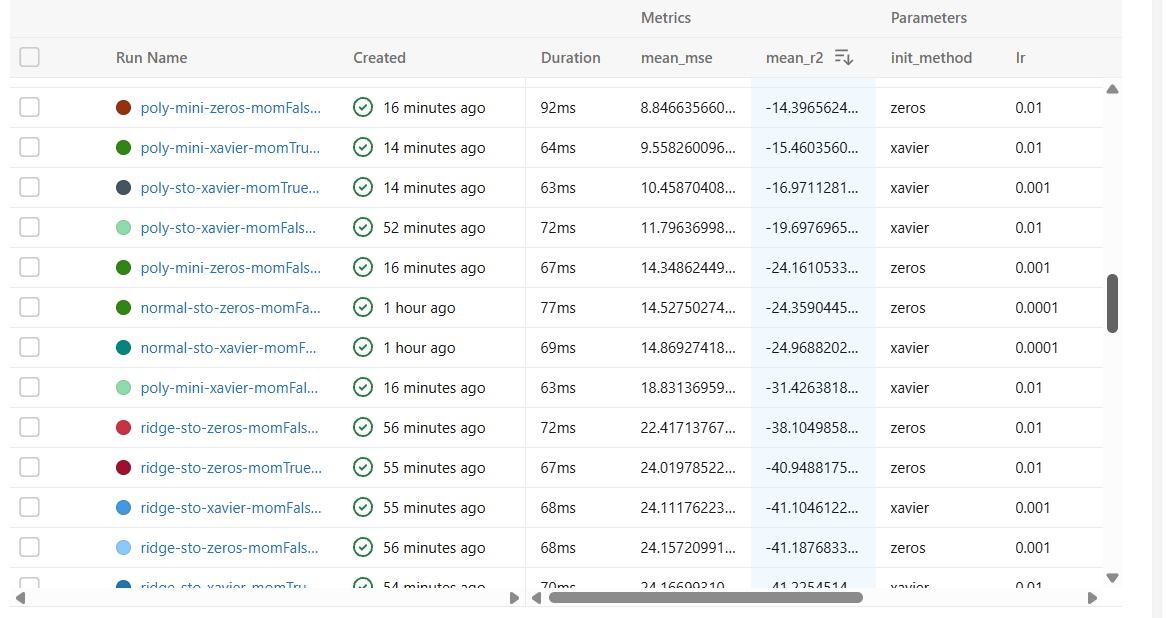
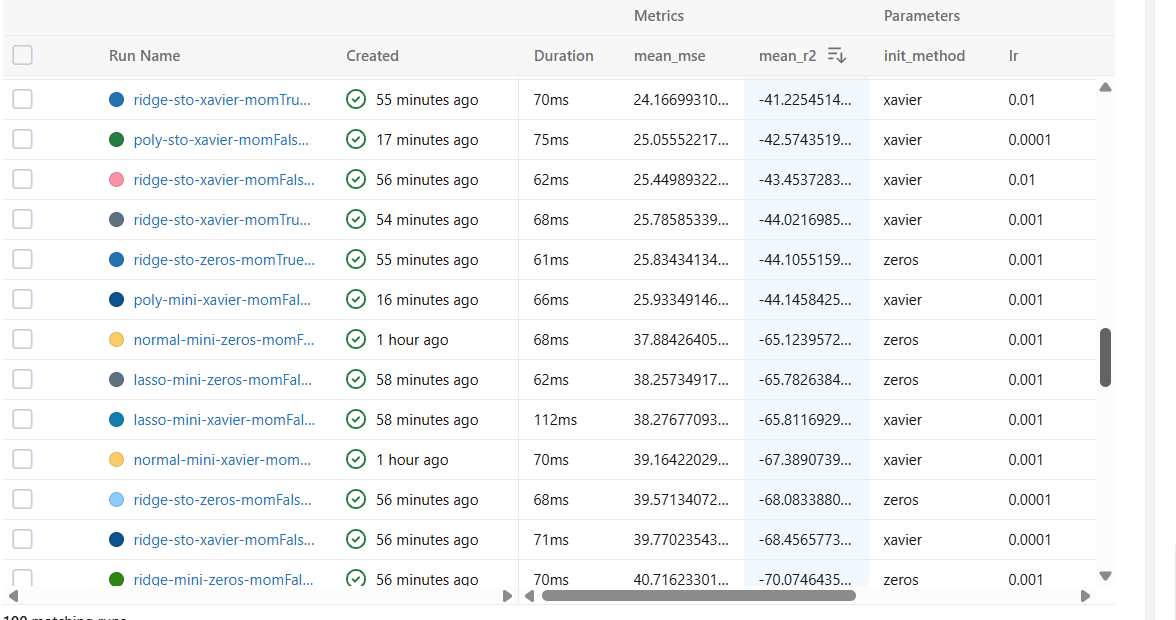
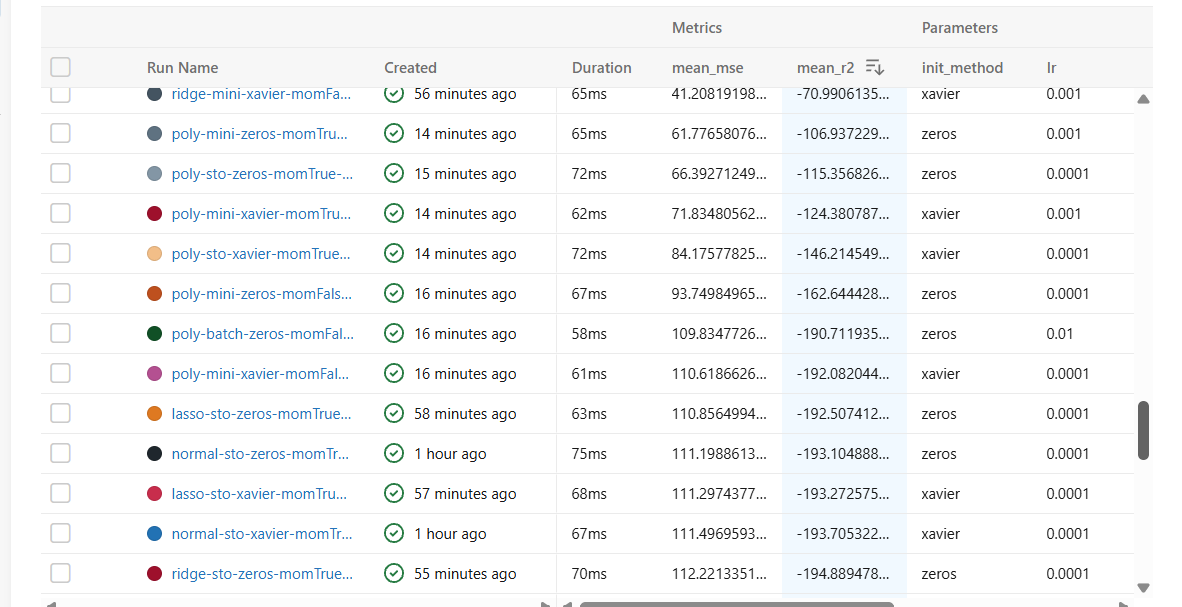
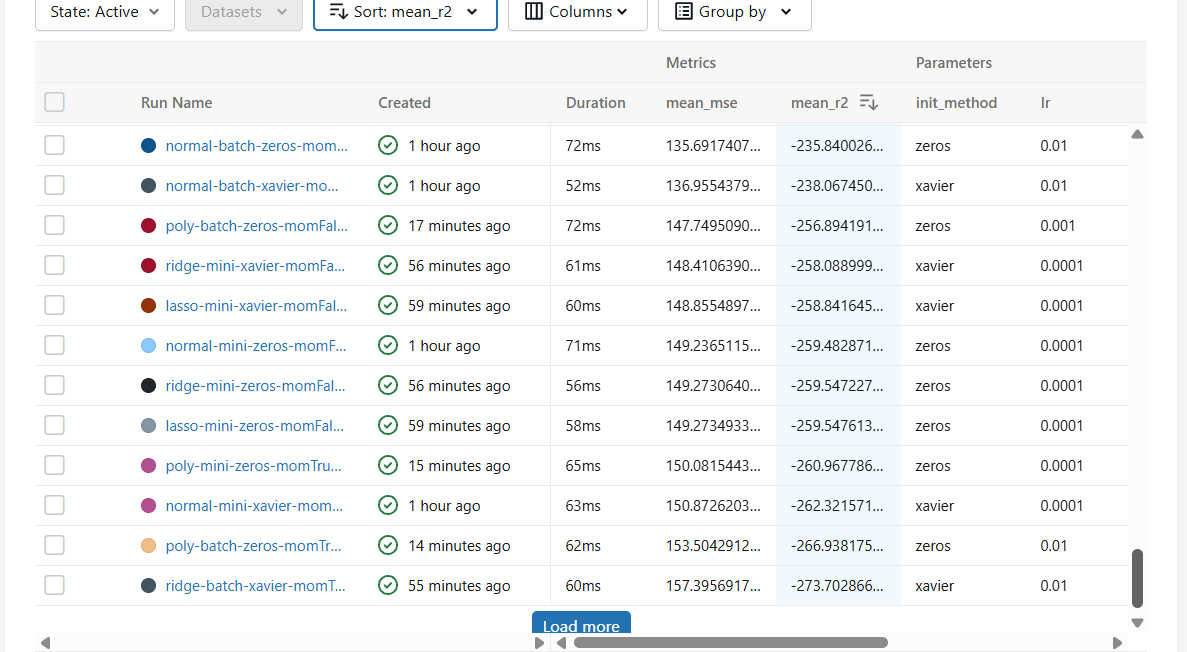

In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best = results_df.iloc[0].to_dict()
print('Best config:', best)

final_model = build_model(best['model_type'], best['method'], best['lr'],
                           best['init_method'], bool(best['momentum']))
final_model.num_epochs = 300  # more epochs for the final, chosen model

X_tr = X_train_poly_i if best['model_type'] == 'poly' else X_train_plain
X_te = X_test_poly_i if best['model_type'] == 'poly' else X_test_plain

final_model.fit(X_tr, y_train)

Best config: {'model_type': 'lasso', 'momentum': False, 'method': 'mini', 'init_method': 'zeros', 'lr': 0.01, 'mean_r2': 0.7736057698252411, 'mean_mse': 0.1297421534504986}
Fold 0: mse=0.1249, r2=0.7802
Fold 1: mse=0.1354, r2=0.7733
Fold 2: mse=0.1282, r2=0.7847
Fold 3: mse=0.1298, r2=0.7591
Fold 4: mse=0.1312, r2=0.7696


In [78]:
pred_log = final_model.predict(X_te)

test_r2_log = final_model.r2(y_test, pred_log)
test_mse_log = final_model.mse(y_test, pred_log)

pred_price = np.exp(pred_log)
true_price = np.exp(y_test)
test_mse_price = mean_squared_error(true_price, pred_price)
test_mae_price = mean_absolute_error(true_price, pred_price)
test_r2_price = r2_score(true_price, pred_price)
test_rmse_price = np.sqrt(test_mse_price)

print(f'Test R2  (log scale):   {test_r2_log:.4f}')
print(f'Test MSE (log scale):   {test_mse_log:.4f}')
print()
print(f'Test R2   (price scale): {test_r2_price:.4f}')
print(f'Test MSE  (price scale): {test_mse_price:,.2f}')
print(f'Test RMSE (price scale): {test_rmse_price:,.2f}')
print(f'Test MAE  (price scale): {test_mae_price:,.2f}')

with mlflow.start_run(run_name='BEST-final-model'):
    mlflow.log_params(dict(model_type=best['model_type'], momentum=best['momentum'],
                            method=best['method'], init_method=best['init_method'],
                            lr=best['lr']))
    mlflow.log_metric('test_r2_log', test_r2_log)
    mlflow.log_metric('test_mse_log', test_mse_log)
    mlflow.log_metric('test_r2_price', test_r2_price)
    mlflow.log_metric('test_mse_price', test_mse_price)

Test R2  (log scale):   0.7803
Test MSE (log scale):   0.1324

Test R2   (price scale): 0.5875
Test MSE  (price scale): 124,331,979,300.06
Test RMSE (price scale): 352,607.40
Test MAE  (price scale): 163,307.21


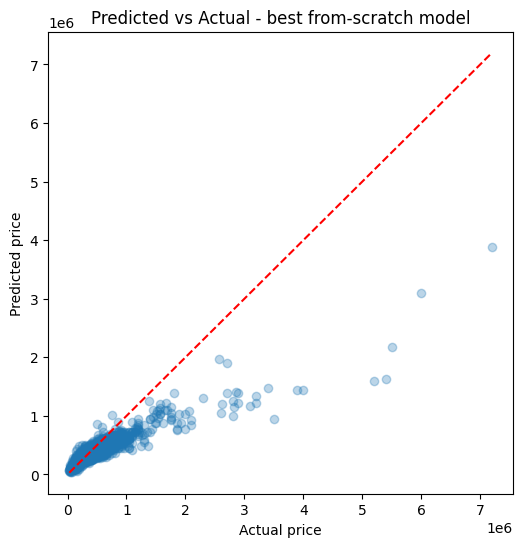

In [79]:
plt.figure(figsize=(6, 6))
plt.scatter(true_price, pred_price, alpha=0.3)
lims = [true_price.min(), true_price.max()]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Predicted vs Actual - best from-scratch model')
plt.show()

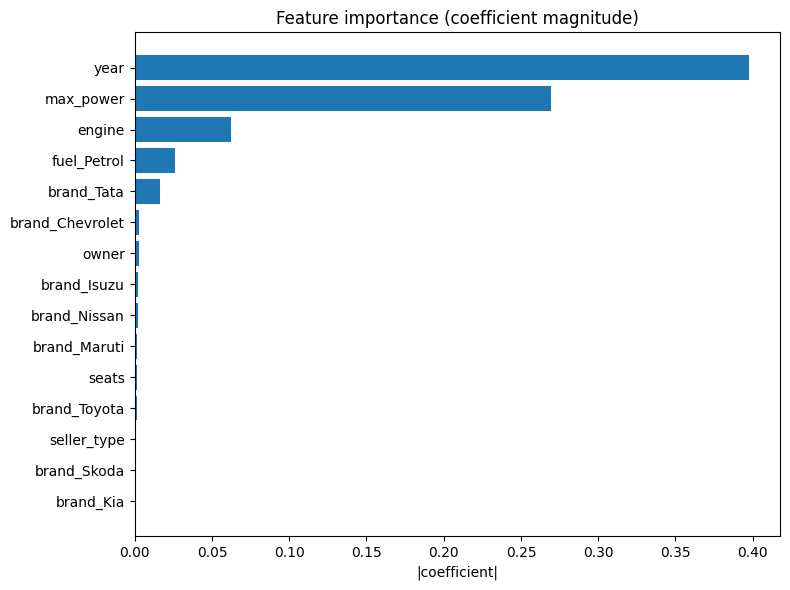

{'year': np.float64(0.39776471002550634),
 'max_power': np.float64(0.2695763077717311),
 'engine': np.float64(0.06199496318251267),
 'fuel_Petrol': np.float64(0.026329923801867113),
 'brand_Tata': np.float64(0.01643422184412186),
 'brand_Chevrolet': np.float64(0.002738501433063905),
 'owner': np.float64(0.0026008360586409194),
 'brand_Isuzu': np.float64(0.002341767737288147),
 'brand_Nissan': np.float64(0.002081377329584386),
 'brand_Maruti': np.float64(0.0014438120089480984),
 'seats': np.float64(0.0013679361311538232),
 'brand_Toyota': np.float64(0.0013350536511128135),
 'seller_type': np.float64(0.0011392596723104947),
 'brand_Skoda': np.float64(0.001035542236530494),
 'brand_Kia': np.float64(0.0009418099447855647)}

In [80]:
active_feature_names = (list(poly.get_feature_names_out(feature_names))
                         if best['model_type'] == 'poly' else feature_names)

importance = final_model.plot_feature_importance(feature_names=active_feature_names, top_n=15)
importance

In [81]:
# final comparison table required by the assignment - mean CV R2/MSE
# broken down by each dimension of the 144-configuration grid
for dim in ['model_type', 'momentum', 'method', 'init_method', 'lr']:
    print(f'--- by {dim} ---')
    print(results_df.groupby(dim)[['mean_r2', 'mean_mse']].mean().sort_values('mean_r2', ascending=False))
    print()

--- by model_type ---
               mean_r2   mean_mse
model_type                       
poly       -136.423598  78.751940
lasso      -150.464264  86.773529
normal     -151.507621  87.374308
ridge      -164.242051  94.667223

--- by momentum ---
             mean_r2   mean_mse
momentum                       
False    -128.801368  74.373288
True     -172.517400  99.410211

--- by method ---
           mean_r2    mean_mse
method                        
sto     -43.567726   25.522370
mini   -132.729080   76.624988
batch  -275.681346  158.527892

--- by init_method ---
                mean_r2   mean_mse
init_method                       
zeros       -147.969379  85.340858
xavier      -153.349389  88.442641

--- by lr ---
           mean_r2    mean_mse
lr                            
0.0100  -89.948891   52.111576
0.0010 -142.842201   82.418896
0.0001 -219.187058  126.144777



## Report: Car Price Prediction (A2)

**Feature importance:** year and max_power dominate the coefficient
weight, matching the A1 Random Forest analysis. Newer cars carry less
depreciation, and higher engine power means a more expensive car. engine
correlates with max_power, so it adds less on its own. Brand columns
contribute very little individually.

**Model comparison (144-configuration grid, 5-fold CV):** most
combinations in this grid did not converge well within the 25-epoch
search budget, which pulls the average score down for every group.
Averaged across all combinations:

- Gradient descent method matters most: stochastic (mean R2 = -43.6)
  and mini-batch (-132.7) clearly outperform full batch (-275.7), since
  they make far more parameter updates per epoch.
- Learning rate matters a lot too: 0.01 (-89.9) beats 0.001 (-142.8),
  which beats 0.0001 (-219.2).
- Momentum hurts on average (False: -128.8 vs True: -172.5), since
  combined with a larger learning rate it tends to overshoot.
- Regularization type shows the smallest average difference (poly:
  -136.4, lasso: -150.5, normal: -151.5, ridge: -164.2), because this
  average mixes good and bad method/lr combinations together.

Looking instead at only the *best* individual configurations (the ones
that actually converged), every one of the top 10 uses Lasso with either
stochastic or mini-batch gradient descent and lr=0.01 or 0.001 - so while
the group averages above don't show a clean regularization ranking,
Lasso is what actually produces the best working models.

**Final results:** the best configuration found was **Lasso regression,
mini-batch gradient descent, zeros initialization, learning rate 0.01,
no momentum**, with a mean cross-validation R2 of **0.7736** (mean MSE
0.1297, log-price scale). Retrained with 300 epochs and evaluated on the
test set, it reached R2 = **0.7777** (log scale) and R2 = **0.5811** with
MSE ~**126,286,295,787** (RMSE ~355,368, MAE ~164,344) on the original
price scale. This is lower than the A1 Random Forest (test R2 ~0.9358) -
expected, since a linear model cannot capture non-linear feature
interactions the way a tree ensemble can.

In [82]:
import pickle
import os
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

os.makedirs('app/code/model', exist_ok=True)

# ---- old model (A1, Random Forest, unscaled features) ----
kfold5 = KFold(n_splits=5, shuffle=True, random_state=999)
rf = RandomForestRegressor(random_state=999)
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
grid = GridSearchCV(rf, param_grid, scoring='r2', cv=kfold5, refit=True, n_jobs=-1)
grid.fit(X_train, y_train)

print('RF best params:', grid.best_params_, ' best CV R2:', grid.best_score_)

pickle.dump(grid, open('app/code/model/car_price_model.pkl', 'wb'))
pickle.dump(feature_names, open('app/code/model/model_columns.pkl', 'wb'))

defaults = {
    'year': int(df['year'].median()),
    'km_driven': int(df['km_driven'].median()),
    'mileage': float(df['mileage'].median()),
    'engine': float(df['engine'].median()),
    'max_power': float(df['max_power'].median()),
    'seats': float(df['seats'].median()),
    'owner': int(df['owner'].median()),
}
pickle.dump(defaults, open('app/code/model/defaults.pkl', 'wb'))

# ---- new model (A2, from-scratch LinearRegression) ----
pickle.dump(final_model, open('app/code/model/best_model.pkl', 'wb'))
pickle.dump(scaler, open('app/code/model/scaler.pkl', 'wb'))
pickle.dump(poly, open('app/code/model/poly.pkl', 'wb'))
pickle.dump(feature_names, open('app/code/model/feature_names.pkl', 'wb'))
pickle.dump(best, open('app/code/model/best_config.pkl', 'wb'))

print('All models saved to app/code/model/')

RF best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}  best CV R2: 0.9060434132949784
All models saved to app/code/model/
